# Playing with MNIST using NumPy

## Introduction to MNIST and Loading from Keras

[MNIST](https://en.wikipedia.org/wiki/MNIST_database) is a classic database in the world of machine learning. It is a database of handwritten digits used to train digit recognition systems. The database contains 60,000 training images and 10,000 test images.

We are downloading this database from Keras and visualizing some of the images.

Keep in mind that when we want to work with images, the first thing we need to do is understand what format they are stored in, and probably do some preprocessing of these images. In this case, the dataset is already preprocessed, with images normalized to 28x28 pixels and in grayscale.

Each pixel has a value representing the intensity in grayscale, between 0 (white) and 255 (black).

In [ ]:
import numpy as np

In [ ]:
import keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

We have used the Keras library, which includes some classic datasets, to download MNIST. In this case, it returns a tuple with the training data and test data. Each of these datasets is in turn a tuple with the images and the labels associated with each image. For example, we can show that `X_train` is a NumPy array of 60,000 images of 28x28 pixels. It therefore has 3 dimensions: 60,000 x 28 x 28.

In [ ]:
print(type(X_train))
print(X_train.dtype) # uint8 (0-255)
print(X_train.shape) # (60000, 28, 28): 60000 images, 28x28 pixels

<class 'numpy.ndarray'>
uint8
(60000, 28, 28)


On the other hand, we can see that `y_train` is a vector containing the labels associated with each image.

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

Let's display the first of the images (`X_train[0]`) by writing the value of each element of the array in a grid:

In [ ]:
def print_image_data_as_pixel_values(image):
    for i in range(28):
        for j in range(28):
            print(f"{image[i][j]:3}", end="")
        print()
        
print_image_data_as_pixel_values(X_train[0])

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

and in a more elegant way, using the **matplotlib** library:

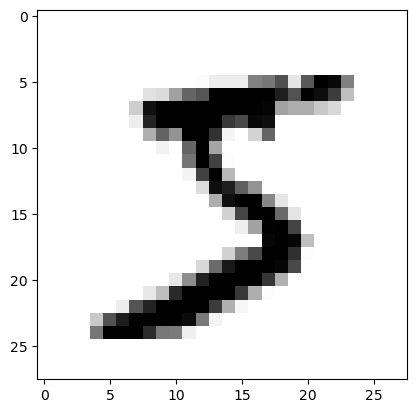

In [ ]:
import matplotlib.pyplot as plt
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.show()
    
plot_image(X_train[0])

and its corresponding label (`y_train[0]`):

In [ ]:
print(y_train[0])

5


Viewing a grid with the first 100 images:

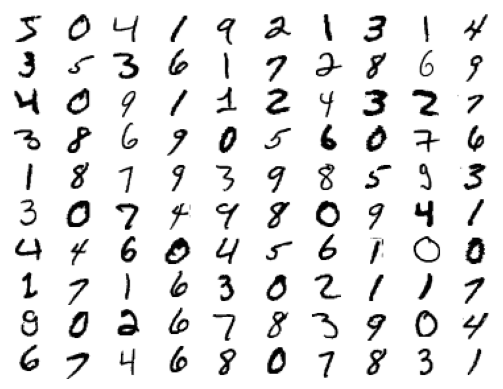

In [ ]:
def print_matrix_first_100(data):
    for idx, image_data in enumerate(data[:100]):
        plt.subplot(10, 10, idx + 1)
        plt.imshow(image_data, cmap="binary")
        plt.axis("off")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

print_matrix_first_100(X_train)

## Exercises

Solve the following exercises, each in its own cell. Use only the NumPy library.

### Basics

1. Create a variable `matrix_first_100_labels` with the first 100 labels in a 10x10 matrix and display them to compare with the previous graphic of their corresponding images.

2. Some *machine learning* models require the input data to be flattened. In this case, that means each image is in a single dimension, or in other words, each 28x28 pixel image is represented by a vector of 784 pixels. Flatten the training and test images, returning two NumPy arrays with dimensions 60,000 x 784 and 10,000 x 784 respectively called `X_train_flat` and `X_test_flat`.

3. Modify the `plot_image` function with which we visualized the first image (`X_train[0]`) so that it also works when receiving flattened images (the same function must be able to receive images of 28*28 or 784). Verify that it works correctly by displaying (`X_train_flat[0]`).

4. Verify that, for all training images, the pixel in the bottom-right corner is always zero.

### One-hot encoding

5. Some *machine learning* models require labels to be encoded in a *one-hot* format. This means that if we have 10 classes (digits from 0 to 9), each label is represented as a vector of 10 elements, where all elements are 0 except the one corresponding to the class, which is 1.

For example, label 5 would be represented as `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`.

Create two variables, `y_train_onehot` and `y_test_onehot`, applying *one-hot encoding* to the labels.

### Normalization

6. Display the following values:
    - Minimum and maximum pixel values of the training images.
    - Mean and standard deviation of the pixels of the training images.

7. Normalize the training images so that the pixel values are in the range [0, 1]. Return an array `X_train_norm` and display the first normalized image.

8. Create the variables `pixel_norm_mean` and `pixel_norm_std` that contain the mean and standard deviation of the pixels from the normalized **training** images. Display these values. You may encounter them in the future.

9. Standardize the training and test images so that they have mean 0 and standard deviation 1. Return `X_train_standardized`.

> **Z-score standardization** (***standard score***) is calculated by first subtracting the mean (so that it becomes 0), and then dividing by the **standard deviation** so that the resulting distribution has standard deviation 1:
>
> $$ X_{std} = \frac{X - \mu}{\sigma} $$
> 
> where $X$ is the input array, $X_{std}$ is the standardized array, $\mu$ is the mean and $\sigma$ is the standard deviation.

10. Apply the standardization process to `X_train_norm`. Return `X_train_norm_standardized` and verify that all its values are equal to those of `X_train_standardized` (you can use `np.allclose()` since they won't be exactly equal due to floating-point calculation precision).

### *Data Augmentation*

11. Create an array `X_train_noisy` containing the training images with Gaussian noise.

> **Gaussian noise is random noise that follows a normal distribution.** It can be applied to images to simulate non-ideal image capture conditions. This can help make *machine learning* models more robust.
>
> You can use the `np.random.normal` function to generate Gaussian noise.

Create the `add_gaussian_noise` function and apply it to the training set. Visualize the first 100 images with the added noise.

12. Binarization

- Create a `binarize_image` function that binarizes an image (converting pixels to 0 or 1). The function should receive an array with the image and a threshold value. If a pixel value is greater than the threshold, it is converted to 1, and if it is less, to 0.
- Create an array `X_train_binarized` containing the binarized training images and visualize the first 100 images.

Try different threshold values (for example, 80, 120, 180) and visualize the first 100 binarized images with each of them.

13. Apply the binarization process to the noisy images, creating a new array `X_train_noisy_binarized`. Try different `threshold` values and visualize the first 100 binarized images.

14. Create a `shift_image` function that shifts an image in a direction (up, down, left, right) by a given number of pixels. The function should receive an array with the image, the displacement in the X axis (`dx`) and the displacement in the Y axis (`dy`).

Visualize several shifted images (for example, the first image shifted 10 pixels to the right, 10 pixels down, 10 pixels to the left, 10 pixels up).

15. Create an array `X_train_shifted_right_10` containing the images from `X_train` shifted 10 pixels to the right. Display the first 100 images.

16. Create a `find_limits` function that receives an image and returns the limits where the image stops being all 0s. It should return a tuple with the values `(top, bottom, left, right)` indicating the image boundaries.

Visualize several images with the boundaries drawn.

17. Create a `crop_image_limits` function that receives an image and returns it cropped to the limits calculated with the `find_limits` function. Test this function with several images.

18. Create an array `X_train_shifted` containing the images by shifting each one in a random direction by a random number of pixels, but ensuring that after cropping to the limits calculated with `find_limits`, the digit remains centered in 20x20 and visible.

19. Create an augmented training set `X_train_augmented` by adding the following transformations to the training images:
- Original images
- Images with Gaussian noise
- Binarized images
- Noisy and binarized images
- Shifted images

Concatenate all these arrays and display the total number of images in the augmented set.